In [316]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Setting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
        
import os
file_count = 0
for dirname, _, filenames in os.walk('./'):
    file_count += len(filenames)
    print(f"{dirname}: {len(filenames)} files")
print(f"\nTotal files: {file_count}")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./: 11 files
./train: 0 files
./train/F: 170 files
./train/O: 174 files
./train/J: 175 files
./train/Y: 176 files
./train/L: 176 files
./train/Ö: 174 files
./train/U: 175 files
./train/S: 174 files
./train/D: 174 files
./train/Õ: 176 files
./train/G: 175 files
./train/C: 174 files
./train/M: 175 files
./train/R: 174 files
./train/H: 176 files
./train/Ü: 161 files
./train/I: 173 files
./train/P: 172 files
./train/N: 172 files
./train/Ä: 175 files
./train/W: 174 files
./train/T: 174 files
./train/B: 174 files
./train/V: 176 files
./train/E: 172 files
./train/A: 168 files
./train/K: 173 files
./.codex: 0 files
./.git: 0 files
./test: 1184 files
./.agents: 0 files

Total files: 5877


In [317]:
# Works both on Kaggle and with the competition files downloaded locally.
possible_base_dirs = [
    Path('/kaggle/input/sign-language-kaggle-comp'),
    Path('/kaggle/input/competitions/sign-language-kaggle-comp'),
    Path('.'),
]

for candidate in possible_base_dirs:
    if (candidate / 'train').exists() and (candidate / 'test').exists():
        base_dir = candidate
        break
else:
    raise FileNotFoundError('Could not find train/ and test/ folders')

train_dir = base_dir / 'train'
test_dir = base_dir / 'test'
sample_submission = base_dir / 'sample_submission.csv'

print(f'Using data from: {base_dir.resolve()}')


Using data from: /home/yash/temp


In [318]:
class_folders = sorted([f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))])
print(f"Number of classes: {len(class_folders)}")
print(f"Classes: {class_folders}")

Number of classes: 27
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'Ä', 'Õ', 'Ö', 'Ü']


In [319]:
# Count images per class
class_counts = {}
for class_name in class_folders:
    class_path = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[class_name] = len(image_files)

print(f"\nTotal training images: {sum(class_counts.values())}")
print(f"Average images per class: {sum(class_counts.values()) / len(class_counts):.1f}")


Total training images: 4682
Average images per class: 173.4


In [320]:
# Count test images
test_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Number of test images: {len(test_images)}")
print(f"\nFirst 5 test image names: {test_images[:5]}")

Number of test images: 1184

First 5 test image names: ['img_00434.jpeg', 'img_00782.jpeg', 'img_00733.jpeg', 'img_00701.jpg', 'img_00071.jpeg']


## Exploratory Data Analysis (EDA)

In [321]:
# Creating a dataframe for easier data manipulation
df_class_dist = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_class_dist = df_class_dist.sort_values('Count', ascending=False).reset_index(drop=True)

# Display statistics
print(f"\nMost common class: {df_class_dist.iloc[0]['Class']} ({df_class_dist.iloc[0]['Count']} images)")
print(f"Least common class: {df_class_dist.iloc[-1]['Class']} ({df_class_dist.iloc[-1]['Count']} images)")


Most common class: Õ (176 images)
Least common class: Ü (161 images)


In [322]:
test_images = os.listdir(test_dir)
first_test = os.path.join(test_dir, test_images[0])

img = Image.open(first_test)
print(f"Test picutre size: {img.size}")

Test picutre size: (480, 360)


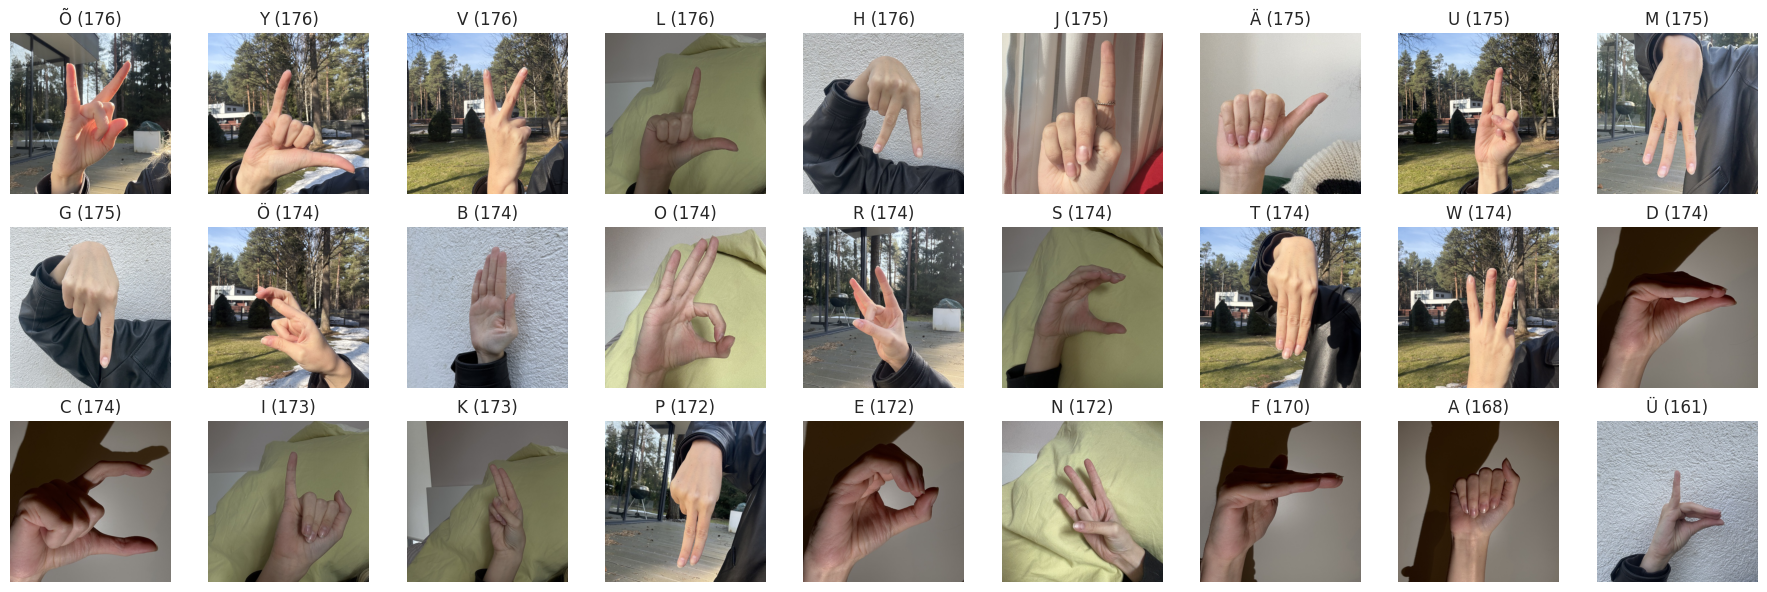

In [323]:
#import matplotlib.pyplot as plt

#train_dir = '/kaggle/input/sign-language-kaggle-comp/train'

fig, axes = plt.subplots(3, 9, figsize=(18, 6))  # 27 klassi
axes = axes.flatten()

for idx, row in df_class_dist.iterrows():
    class_name = row['Class']
    class_folder = os.path.join(train_dir, class_name)
    
    # Taking the first image
    first_image = os.listdir(class_folder)[0]
    img_path = os.path.join(class_folder, first_image)
    
    img = Image.open(img_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_name} ({row['Count']})")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [324]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3090


## Train a timm image classifier

This version uses a stratified 85/15 train/validation split so we can see whether training accuracy is translating into held-out accuracy. The test folder is still used only for final inference/submission because Kaggle test labels are hidden.


In [325]:
SEED = 42
MODEL_NAME = 'resnet18'
PRETRAINED = True
IMG_SIZE = 256
BATCH_SIZE = 64
EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA is not available. This notebook is configured for GPU training. '
        'Fix the NVIDIA driver / CUDA visibility first, then rerun.'
    )

device = torch.device('cuda')
print(f'Using device: {device} - {torch.cuda.get_device_name(0)}')
print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, NUM_WORKERS={NUM_WORKERS}')


Using device: cuda - NVIDIA GeForce RTX 3090
IMG_SIZE=256, BATCH_SIZE=64, EPOCHS=20, NUM_WORKERS=4


### Class balance

The classes are already very close in size, so this baseline does not use class weights or oversampling. The split below preserves class proportions in train and validation.


In [326]:
class_counts = {}
for class_name in sorted(os.listdir(train_dir)):
    class_path = train_dir / class_name
    if class_path.is_dir():
        class_counts[class_name] = len([
            p for p in class_path.iterdir()
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
        ])

class_count_df = pd.DataFrame(
    {'Class': list(class_counts.keys()), 'Count': list(class_counts.values())}
).sort_values('Class').reset_index(drop=True)

display(class_count_df)

min_class = class_count_df.loc[class_count_df['Count'].idxmin()]
max_class = class_count_df.loc[class_count_df['Count'].idxmax()]
print(f"Total training images: {class_count_df['Count'].sum()}")
print(f"Smallest class: {min_class['Class']} ({min_class['Count']})")
print(f"Largest class: {max_class['Class']} ({max_class['Count']})")
print(f"Max/min ratio: {max_class['Count'] / min_class['Count']:.3f}")


,Class,Count
0,A,168
1,B,174
2,C,174
3,D,174
4,E,172
5,F,170
6,G,175
7,H,176
8,I,173
9,J,175


Total training images: 4682
Smallest class: Ü (161)
Largest class: H (176)
Max/min ratio: 1.093


### Transforms

The model stays RGB because pretrained `timm` backbones expect 3-channel ImageNet-style input. Color is not the main signal, but keeping RGB preserves pretrained features and can still help with skin/background separation. No horizontal flip is used.


### Augmentation sampling policy

For each training image, there is a 70% chance of entering augmentation mode and a 30% chance of keeping the image clean apart from final resizing and normalization. If augmentation mode is enabled, exactly 3 candidate operations are sampled uniformly from the augmentation list. Each of those 3 candidates is then independently applied with probability 0.66.


In [327]:
# Keep this cell runnable even after restarting or rerunning out of order.
import random
import io
import numpy as np
import torch
from PIL import Image, ImageFilter, ImageOps, ImageDraw
from torchvision import transforms
from torchvision.transforms import InterpolationMode


class RandomJPEGCompression:
    def __init__(self, quality=(35, 85), p=1.0):
        self.quality = quality
        self.p = p

    def __call__(self, image):
        if random.random() > self.p:
            return image
        quality = random.randint(self.quality[0], self.quality[1])
        buffer = io.BytesIO()
        image.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert('RGB')


class RandomMotionBlur:
    def __init__(self, kernel_size=5, p=1.0):
        if kernel_size % 2 == 0:
            raise ValueError('kernel_size must be odd')
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image):
        if random.random() > self.p:
            return image

        k = self.kernel_size
        direction = random.choice(['horizontal', 'vertical'])
        kernel = [0.0] * (k * k)
        if direction == 'horizontal':
            center_row = k // 2
            for col in range(k):
                kernel[center_row * k + col] = 1.0 / k
        else:
            center_col = k // 2
            for row in range(k):
                kernel[row * k + center_col] = 1.0 / k

        return image.filter(ImageFilter.Kernel((k, k), kernel, scale=1.0))


class PILGaussianNoise:
    def __init__(self, std=0.06):
        self.std = std

    def __call__(self, image):
        arr = np.asarray(image).astype(np.float32) / 255.0
        arr = np.clip(arr + np.random.normal(0.0, self.std, arr.shape), 0.0, 1.0)
        return Image.fromarray((arr * 255).astype(np.uint8))


class PILRandomErasing:
    def __init__(self, scale=(0.02, 0.10), ratio=(0.3, 3.3)):
        self.scale = scale
        self.ratio = ratio

    def __call__(self, image):
        image = image.copy()
        width, height = image.size
        area = width * height

        for _ in range(10):
            erase_area = random.uniform(*self.scale) * area
            aspect = random.uniform(*self.ratio)
            erase_w = int(round((erase_area * aspect) ** 0.5))
            erase_h = int(round((erase_area / aspect) ** 0.5))
            if erase_w < width and erase_h < height:
                x0 = random.randint(0, width - erase_w)
                y0 = random.randint(0, height - erase_h)
                arr = np.asarray(image).copy()
                noise_patch = np.random.randint(0, 256, size=(erase_h, erase_w, 3), dtype=np.uint8)
                arr[y0:y0 + erase_h, x0:x0 + erase_w, :] = noise_patch
                return Image.fromarray(arr)
        return image


class RandomSubsetAugment:
    def __init__(self, ops, p=0.70, op_p=0.66, num_candidates=3):
        self.ops = ops
        self.p = p
        self.op_p = op_p
        self.num_candidates = num_candidates

    def __call__(self, image):
        if random.random() > self.p:
            return image

        candidates = random.sample(self.ops, k=min(self.num_candidates, len(self.ops)))
        random.shuffle(candidates)

        for _, op in candidates:
            if random.random() < self.op_p:
                image = op(image)
        return image


imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

augmentation_ops = [
    ('small random crop', transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.70, 1.00),
        ratio=(0.85, 1.15),
        interpolation=InterpolationMode.BILINEAR,
    )),
    ('perspective', transforms.RandomPerspective(distortion_scale=0.35, p=1.0, interpolation=InterpolationMode.BILINEAR)),
    ('rotation/shear/affine', transforms.RandomAffine(
        degrees=90,
        translate=(0.08, 0.08),
        scale=(0.85, 1.15),
        shear=(-15, 15, -10, 10),
        interpolation=InterpolationMode.BILINEAR,
        fill=(128, 128, 128),
    )),
    ('brightness/contrast/hue', transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.20, hue=0.06)),
    ('grayscale', transforms.RandomGrayscale(p=1.0)),
    ('invert', transforms.RandomInvert(p=1.0)),
    ('posterize', transforms.RandomPosterize(bits=4, p=1.0)),
    ('autocontrast', transforms.RandomAutocontrast(p=1.0)),
    ('jpeg compression', RandomJPEGCompression(quality=(35, 85), p=1.0)),
    ('motion blur', RandomMotionBlur(kernel_size=5, p=1.0)),
    ('gaussian blur', transforms.GaussianBlur(kernel_size=7, sigma=(0.3, 2.5))),
    ('gaussian noise', PILGaussianNoise(std=0.06)),
    ('random erasing', PILRandomErasing(scale=(0.02, 0.10), ratio=(0.3, 3.3))),
]

train_tfms = transforms.Compose([
    RandomSubsetAugment(augmentation_ops, p=0.70, op_p=0.66, num_candidates=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


## Visualize augmentations

Run this before training to inspect whether the augmentation strength still preserves the sign label.


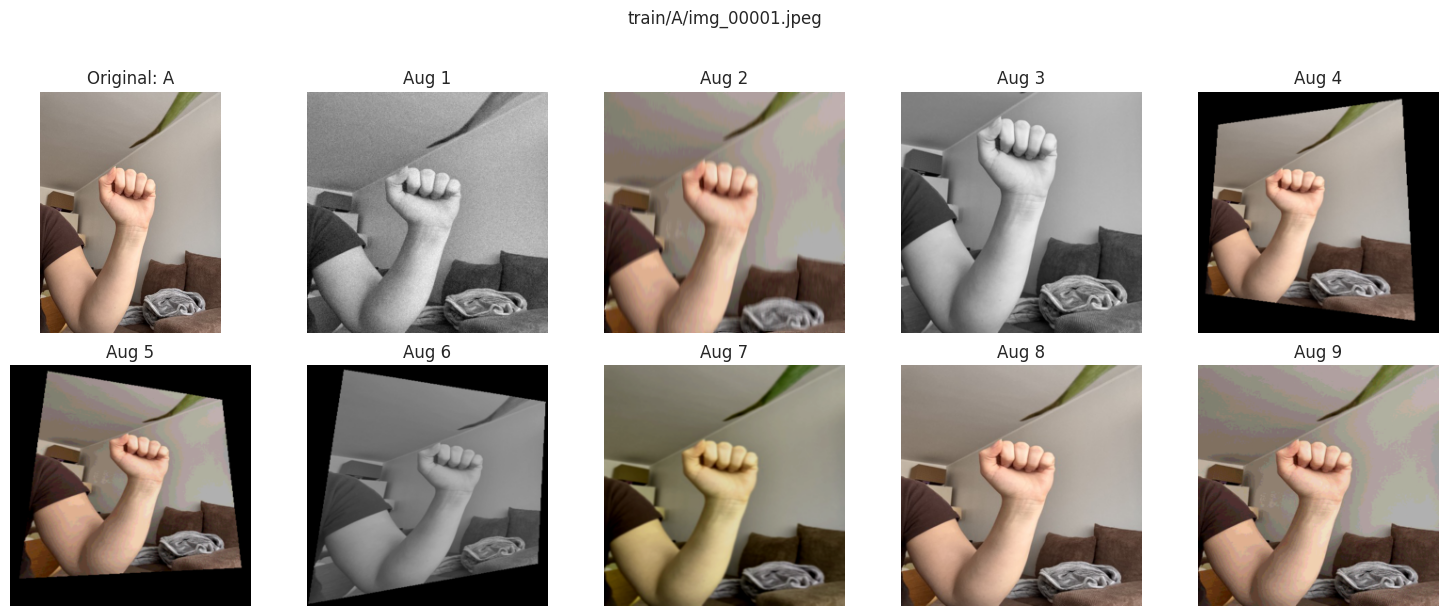

In [328]:
def denormalize_image(tensor, mean=imagenet_mean, std=imagenet_std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    tensor = tensor.detach().cpu() * std + mean
    return tensor.clamp(0, 1).permute(1, 2, 0).numpy()


def show_augmentations(class_name=None, image_index=0, n_augmented=8):
    if class_name is None:
        class_name = class_names[0] if 'class_names' in globals() else sorted(os.listdir(train_dir))[0]

    class_path = train_dir / class_name
    image_paths = sorted([
        p for p in class_path.iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
    ])
    image_path = image_paths[image_index % len(image_paths)]
    original = ImageOps.exif_transpose(Image.open(image_path)).convert('RGB')

    cols = 5
    rows = int(np.ceil((n_augmented + 1) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(original)
    axes[0].set_title(f'Original: {class_name}')
    axes[0].axis('off')

    for i in range(n_augmented):
        augmented = train_tfms(original)
        axes[i + 1].imshow(denormalize_image(augmented))
        axes[i + 1].set_title(f'Aug {i + 1}')
        axes[i + 1].axis('off')

    for ax in axes[n_augmented + 1:]:
        ax.axis('off')

    plt.suptitle(str(image_path), y=1.02)
    plt.tight_layout()
    plt.show()


# Change class_name/image_index to inspect hard classes or specific examples.
show_augmentations(class_name=None, image_index=0, n_augmented=9)


## Visualize individual augmentations

This shows each augmentation type separately on the same image, so you can judge which ones are too weak or too destructive.


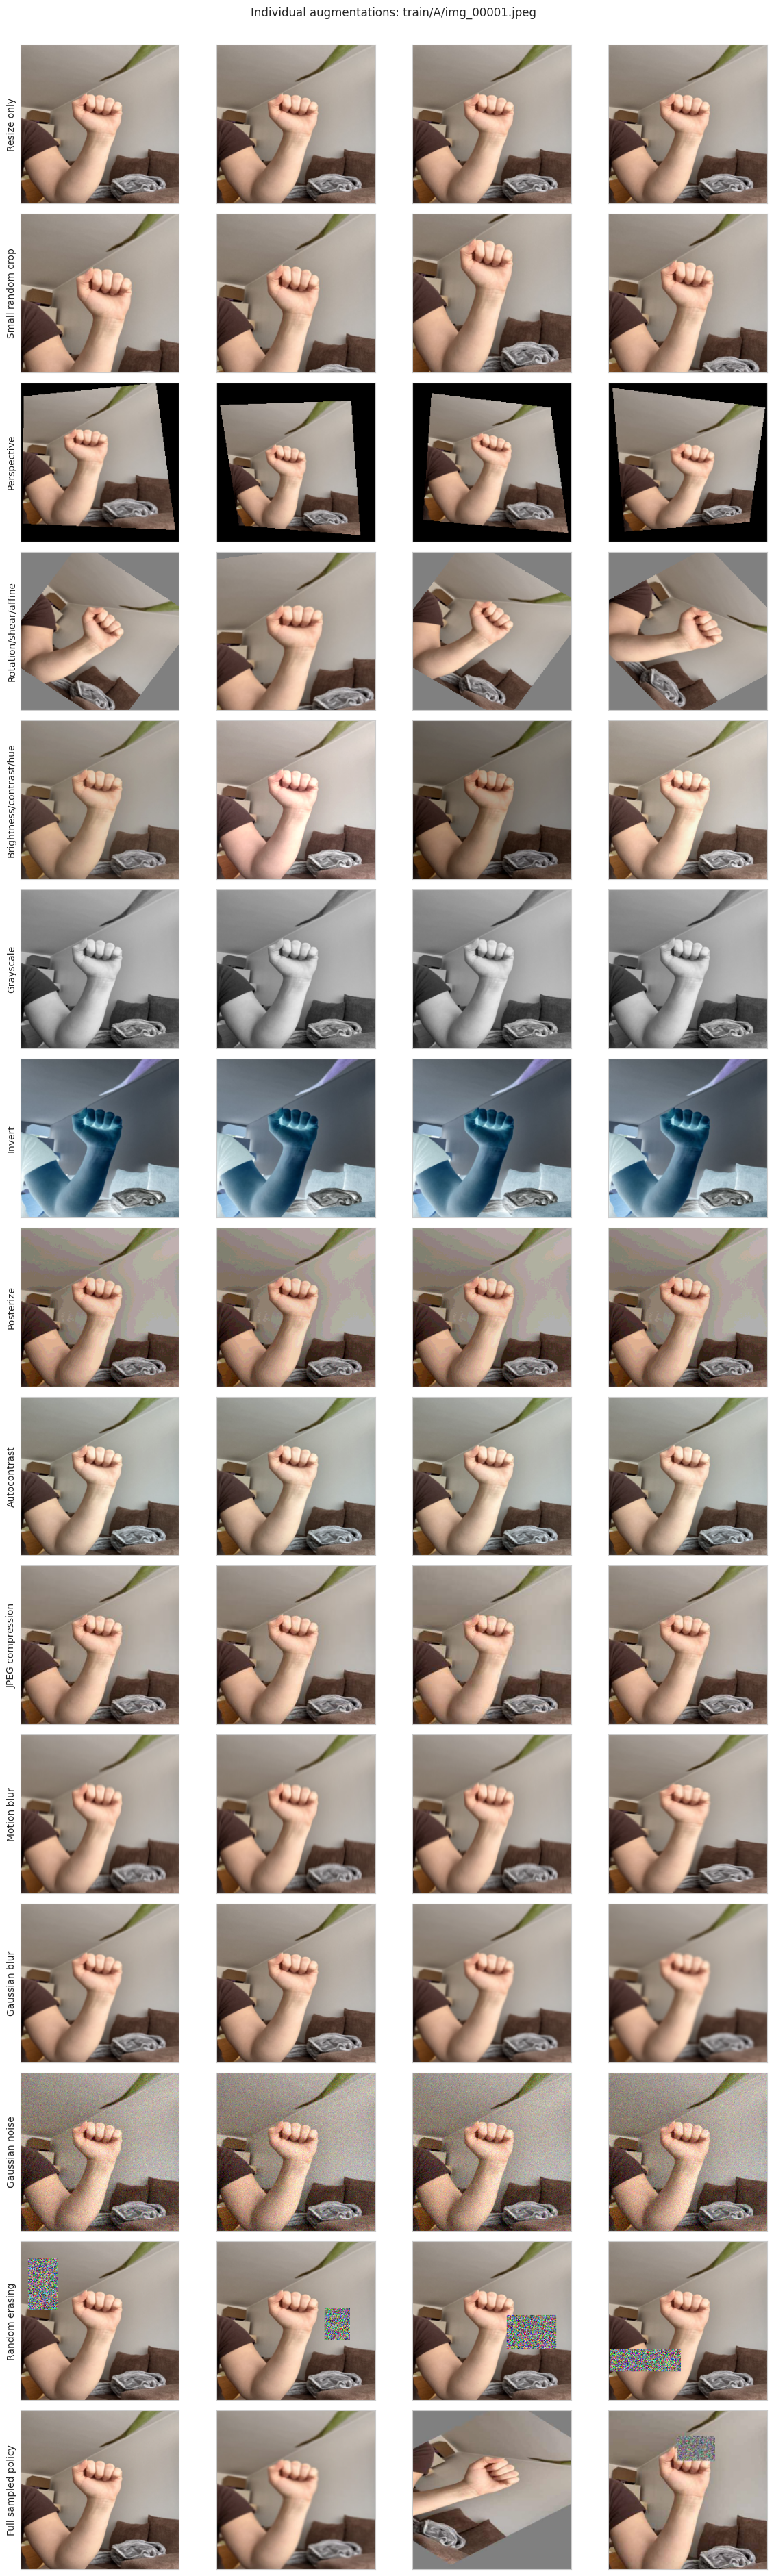

In [329]:
def show_individual_augmentations(class_name=None, image_index=0, repeats=4):
    if class_name is None:
        class_name = class_names[0] if 'class_names' in globals() else sorted(os.listdir(train_dir))[0]

    class_path = train_dir / class_name
    image_paths = sorted([
        p for p in class_path.iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
    ])
    image_path = image_paths[image_index % len(image_paths)]
    original = ImageOps.exif_transpose(Image.open(image_path)).convert('RGB')

    individual_aug_pipelines = {
        'Resize only': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
        ]),
        'Small random crop': transforms.Compose([
            transforms.RandomResizedCrop(IMG_SIZE, scale=(0.70, 1.00), ratio=(0.85, 1.15), interpolation=InterpolationMode.BILINEAR),
        ]),
        'Perspective': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomPerspective(distortion_scale=0.35, p=1.0, interpolation=InterpolationMode.BILINEAR),
        ]),
        'Rotation/shear/affine': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomAffine(
                degrees=90,
                translate=(0.08, 0.08),
                scale=(0.85, 1.15),
                shear=(-15, 15, -10, 10),
                interpolation=InterpolationMode.BILINEAR,
                fill=(128, 128, 128),
            ),
        ]),
        'Brightness/contrast/hue': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.20, hue=0.06),
        ]),
        'Grayscale': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomGrayscale(p=1.0),
        ]),
        'Invert': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomInvert(p=1.0),
        ]),
        'Posterize': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomPosterize(bits=4, p=1.0),
        ]),
        'Autocontrast': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomAutocontrast(p=1.0),
        ]),
        'JPEG compression': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            RandomJPEGCompression(quality=(35, 85), p=1.0),
        ]),
        'Motion blur': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            RandomMotionBlur(kernel_size=5, p=1.0),
        ]),
        'Gaussian blur': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            transforms.GaussianBlur(kernel_size=7, sigma=(0.3, 2.5)),
        ]),
        'Gaussian noise': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            PILGaussianNoise(std=0.06),
        ]),
        'Random erasing': transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
            PILRandomErasing(scale=(0.02, 0.10), ratio=(0.3, 3.3)),
        ]),
        'Full sampled policy': train_tfms,
    }

    rows = len(individual_aug_pipelines)
    cols = repeats
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.5))

    for row_idx, (aug_name, aug) in enumerate(individual_aug_pipelines.items()):
        for col_idx in range(cols):
            ax = axes[row_idx, col_idx]
            augmented = aug(original)

            if isinstance(augmented, Image.Image):
                ax.imshow(augmented)
            else:
                if aug_name == 'Full sampled policy':
                    ax.imshow(denormalize_image(augmented))
                else:
                    ax.imshow(augmented.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy())

            if col_idx == 0:
                ax.set_ylabel(aug_name, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle(f'Individual augmentations: {image_path}', y=1.002)
    plt.tight_layout()
    plt.show()


show_individual_augmentations(class_name=None, image_index=0, repeats=4)


In [332]:
# Keep this cell runnable even after restarting or rerunning out of order.
from collections import defaultdict
from PIL import Image, ImageOps
from torchvision import datasets
from torch.utils.data import DataLoader, Subset


def exif_corrected_pil_loader(path):
    with open(path, 'rb') as f:
        image = Image.open(f)
        image = ImageOps.exif_transpose(image)
        return image.convert('RGB')


full_train_dataset = datasets.ImageFolder(train_dir, transform=None, loader=exif_corrected_pil_loader)
class_names = full_train_dataset.classes
num_classes = len(class_names)
idx_to_class = {idx: class_name for class_name, idx in full_train_dataset.class_to_idx.items()}

indices_by_class = defaultdict(list)
for idx, (_, target) in enumerate(full_train_dataset.samples):
    indices_by_class[target].append(idx)

rng = np.random.default_rng(SEED)
train_indices = []
val_indices = []

# Set to 0.15 for validation experiments. Set to 0.0 for final full-data training.
VAL_FRACTION = 0.10
HAS_VALIDATION = VAL_FRACTION > 0

for target, indices in sorted(indices_by_class.items()):
    indices = np.array(indices)
    rng.shuffle(indices)
    if HAS_VALIDATION:
        n_val = max(1, int(round(len(indices) * VAL_FRACTION)))
    else:
        n_val = 0
    val_indices.extend(indices[:n_val].tolist())
    train_indices.extend(indices[n_val:].tolist())

rng.shuffle(train_indices)
rng.shuffle(val_indices)

train_dataset_for_split = datasets.ImageFolder(train_dir, transform=train_tfms, loader=exif_corrected_pil_loader)
train_dataset = Subset(train_dataset_for_split, train_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

if HAS_VALIDATION:
    val_dataset_for_split = datasets.ImageFolder(train_dir, transform=test_tfms, loader=exif_corrected_pil_loader)
    val_dataset = Subset(val_dataset_for_split, val_indices)
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )
else:
    val_dataset = None
    val_loader = None

RESNET_CHECKPOINT_PATH = 'best_val_model.pth' if HAS_VALIDATION else 'final_full_train_model.pth'
CONVNEXT_CHECKPOINT_PATH = 'best_val_convnextv2_tiny.pth' if HAS_VALIDATION else 'final_full_train_convnextv2_tiny.pth'

print(f'Classes ({num_classes}): {class_names}')
print(f'Validation enabled: {HAS_VALIDATION} (VAL_FRACTION={VAL_FRACTION})')
print(f'Train images: {len(train_dataset)}')
print(f'Validation images: {len(val_dataset) if val_dataset is not None else 0}')
print(f'Training batches per epoch: {len(train_loader)}')
print(f'Validation batches per epoch: {len(val_loader) if val_loader is not None else 0}')
print(f'ResNet checkpoint path: {RESNET_CHECKPOINT_PATH}')
print(f'ConvNeXt checkpoint path: {CONVNEXT_CHECKPOINT_PATH}')
print('Class mapping:', full_train_dataset.class_to_idx)


Classes (27): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'Ä', 'Õ', 'Ö', 'Ü']
Validation enabled: True (VAL_FRACTION=0.1)
Train images: 4214
Validation images: 468
Training batches per epoch: 66
Validation batches per epoch: 4
ResNet checkpoint path: best_val_model.pth
ConvNeXt checkpoint path: best_val_convnextv2_tiny.pth
Class mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'R': 16, 'S': 17, 'T': 18, 'U': 19, 'V': 20, 'W': 21, 'Y': 22, 'Ä': 23, 'Õ': 24, 'Ö': 25, 'Ü': 26}


In [333]:
import timm
import torch.nn as nn
def build_model(model_name, num_classes, pretrained=True):
    try:
        return timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    except Exception as exc:
        if pretrained:
            print(f'Could not load pretrained weights: {exc}')
            print('Falling back to random initialization. Enable internet or attach weights for a stronger run.')
            return timm.create_model(model_name, pretrained=False, num_classes=num_classes)
        raise


model = build_model(MODEL_NAME, num_classes, pretrained=PRETRAINED).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
use_amp = device.type == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f'Model: {MODEL_NAME}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Model: resnet18
Parameters: 11,190,363


In [ ]:
history = []
best_val_acc = -1.0
best_val_loss = float('inf')
best_train_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += batch_size

    train_loss = running_loss / total
    train_acc = correct / total

    if HAS_VALIDATION:
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                if use_amp:
                    with torch.cuda.amp.autocast():
                        logits = model(images)
                        loss = criterion(logits, targets)
                else:
                    logits = model(images)
                    loss = criterion(logits, targets)

                batch_size = images.size(0)
                val_running_loss += loss.item() * batch_size
                val_correct += (logits.argmax(dim=1) == targets).sum().item()
                val_total += batch_size

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
    else:
        val_loss = np.nan
        val_acc = np.nan

    scheduler.step()
    elapsed = time.time() - start_time

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'lr': optimizer.param_groups[0]['lr'],
    })

    if HAS_VALIDATION:
        print(
            f'Epoch {epoch:02d}/{EPOCHS} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | '
            f'lr={optimizer.param_groups[0]["lr"]:.2e} | {elapsed:.1f}s'
        )
        is_best = val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss)
        if is_best:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save({
                'model_name': MODEL_NAME,
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'img_size': IMG_SIZE,
                'val_acc': best_val_acc,
                'val_loss': best_val_loss,
                'epoch': epoch,
                'has_validation': True,
            }, RESNET_CHECKPOINT_PATH)
            print(f'  saved {RESNET_CHECKPOINT_PATH} | val_acc={best_val_acc:.4f}')
    else:
        print(
            f'Epoch {epoch:02d}/{EPOCHS} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'lr={optimizer.param_groups[0]["lr"]:.2e} | {elapsed:.1f}s'
        )
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            torch.save({
                'model_name': MODEL_NAME,
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'img_size': IMG_SIZE,
                'train_loss': best_train_loss,
                'epoch': epoch,
                'has_validation': False,
            }, RESNET_CHECKPOINT_PATH)
            print(f'  saved {RESNET_CHECKPOINT_PATH} | train_loss={best_train_loss:.4f}')

history_df = pd.DataFrame(history)
display(history_df)


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
if HAS_VALIDATION:
    plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_acc'], marker='o', label='train')
if HAS_VALIDATION:
    plt.plot(history_df['epoch'], history_df['val_acc'], marker='o', label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Second model: ConvNeXtV2 Tiny

This keeps the ResNet baseline above intact and trains a stronger pretrained `timm` model as a second experiment. The backbone is mostly frozen: only ConvNeXtV2 stages 2 and 3 plus the classification head are trainable.

In [ ]:
import torch
import torch.nn as nn
import timm

CONVNEXT_MODEL_NAME = 'convnextv2_tiny.fcmae_ft_in22k_in1k'
CONVNEXT_EPOCHS = 20
CONVNEXT_LR = 1e-4
CONVNEXT_WEIGHT_DECAY = 1e-4


def build_convnext_model(model_name, num_classes, pretrained=True):
    return timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)


def freeze_convnext_except_last_two_stages(model):
    trainable_prefixes = ('stages.2', 'stages.3', 'head')
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith(trainable_prefixes)
    return model


convnext_model = build_convnext_model(CONVNEXT_MODEL_NAME, num_classes, pretrained=True).to(device)
convnext_model = freeze_convnext_except_last_two_stages(convnext_model)

convnext_trainable_params = sum(p.numel() for p in convnext_model.parameters() if p.requires_grad)
convnext_total_params = sum(p.numel() for p in convnext_model.parameters())

print(f'Model: {CONVNEXT_MODEL_NAME}')
print(f'Total parameters: {convnext_total_params:,}')
print(f'Trainable parameters: {convnext_trainable_params:,}')
print(f'Frozen parameters: {convnext_total_params - convnext_trainable_params:,}')

for name, param in convnext_model.named_parameters():
    if param.requires_grad:
        print('trainable:', name)


Model: convnextv2_tiny.fcmae_ft_in22k_in1k
Total parameters: 27,887,259
Trainable parameters: 26,646,171
Frozen parameters: 1,241,088
trainable: stages.2.downsample.0.weight
trainable: stages.2.downsample.0.bias
trainable: stages.2.downsample.1.weight
trainable: stages.2.downsample.1.bias
trainable: stages.2.blocks.0.conv_dw.weight
trainable: stages.2.blocks.0.conv_dw.bias
trainable: stages.2.blocks.0.norm.weight
trainable: stages.2.blocks.0.norm.bias
trainable: stages.2.blocks.0.mlp.fc1.weight
trainable: stages.2.blocks.0.mlp.fc1.bias
trainable: stages.2.blocks.0.mlp.grn.weight
trainable: stages.2.blocks.0.mlp.grn.bias
trainable: stages.2.blocks.0.mlp.fc2.weight
trainable: stages.2.blocks.0.mlp.fc2.bias
trainable: stages.2.blocks.1.conv_dw.weight
trainable: stages.2.blocks.1.conv_dw.bias
trainable: stages.2.blocks.1.norm.weight
trainable: stages.2.blocks.1.norm.bias
trainable: stages.2.blocks.1.mlp.fc1.weight
trainable: stages.2.blocks.1.mlp.fc1.bias
trainable: stages.2.blocks.1.mlp.g

In [335]:
convnext_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
convnext_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, convnext_model.parameters()),
    lr=CONVNEXT_LR,
    weight_decay=CONVNEXT_WEIGHT_DECAY,
)
convnext_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(convnext_optimizer, T_max=CONVNEXT_EPOCHS)
convnext_scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

convnext_history = []
best_convnext_val_acc = -1.0
best_convnext_val_loss = float('inf')
best_convnext_train_loss = float('inf')

for epoch in range(1, CONVNEXT_EPOCHS + 1):
    start_time = time.time()
    convnext_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        convnext_optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                logits = convnext_model(images)
                loss = convnext_criterion(logits, targets)
            convnext_scaler.scale(loss).backward()
            convnext_scaler.step(convnext_optimizer)
            convnext_scaler.update()
        else:
            logits = convnext_model(images)
            loss = convnext_criterion(logits, targets)
            loss.backward()
            convnext_optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += batch_size

    train_loss = running_loss / total
    train_acc = correct / total

    if HAS_VALIDATION:
        convnext_model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                if use_amp:
                    with torch.cuda.amp.autocast():
                        logits = convnext_model(images)
                        loss = convnext_criterion(logits, targets)
                else:
                    logits = convnext_model(images)
                    loss = convnext_criterion(logits, targets)

                batch_size = images.size(0)
                val_running_loss += loss.item() * batch_size
                val_correct += (logits.argmax(dim=1) == targets).sum().item()
                val_total += batch_size

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
    else:
        val_loss = np.nan
        val_acc = np.nan

    convnext_scheduler.step()
    elapsed = time.time() - start_time

    convnext_history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'lr': convnext_optimizer.param_groups[0]['lr'],
    })

    if HAS_VALIDATION:
        print(
            f'ConvNeXtV2 epoch {epoch:02d}/{CONVNEXT_EPOCHS} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | '
            f'lr={convnext_optimizer.param_groups[0]["lr"]:.2e} | {elapsed:.1f}s'
        )
        is_best = val_acc > best_convnext_val_acc or (val_acc == best_convnext_val_acc and val_loss < best_convnext_val_loss)
        if is_best:
            best_convnext_val_acc = val_acc
            best_convnext_val_loss = val_loss
            torch.save({
                'model_name': CONVNEXT_MODEL_NAME,
                'model_state_dict': convnext_model.state_dict(),
                'class_names': class_names,
                'img_size': IMG_SIZE,
                'val_acc': best_convnext_val_acc,
                'val_loss': best_convnext_val_loss,
                'epoch': epoch,
                'trainable': 'stages.2, stages.3, head',
                'has_validation': True,
            }, CONVNEXT_CHECKPOINT_PATH)
            print(f'  saved {CONVNEXT_CHECKPOINT_PATH} | val_acc={best_convnext_val_acc:.4f}')
    else:
        print(
            f'ConvNeXtV2 epoch {epoch:02d}/{CONVNEXT_EPOCHS} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'lr={convnext_optimizer.param_groups[0]["lr"]:.2e} | {elapsed:.1f}s'
        )
        if train_loss < best_convnext_train_loss:
            best_convnext_train_loss = train_loss
            torch.save({
                'model_name': CONVNEXT_MODEL_NAME,
                'model_state_dict': convnext_model.state_dict(),
                'class_names': class_names,
                'img_size': IMG_SIZE,
                'train_loss': best_convnext_train_loss,
                'epoch': epoch,
                'trainable': 'stages.2, stages.3, head',
                'has_validation': False,
            }, CONVNEXT_CHECKPOINT_PATH)
            print(f'  saved {CONVNEXT_CHECKPOINT_PATH} | train_loss={best_convnext_train_loss:.4f}')

convnext_history_df = pd.DataFrame(convnext_history)
display(convnext_history_df)


ConvNeXtV2 epoch 01/30 | train_loss=2.7388 | train_acc=0.2634 | val_loss=1.6625 | val_acc=0.6752 | lr=2.99e-05 | 12.7s
  saved best_val_convnextv2_tiny.pth | val_acc=0.6752
ConvNeXtV2 epoch 02/30 | train_loss=1.1237 | train_acc=0.8149 | val_loss=0.6725 | val_acc=0.9338 | lr=2.97e-05 | 12.3s
  saved best_val_convnextv2_tiny.pth | val_acc=0.9338
ConvNeXtV2 epoch 03/30 | train_loss=0.6432 | train_acc=0.9293 | val_loss=0.5108 | val_acc=0.9744 | lr=2.93e-05 | 12.2s
  saved best_val_convnextv2_tiny.pth | val_acc=0.9744
ConvNeXtV2 epoch 04/30 | train_loss=0.5269 | train_acc=0.9627 | val_loss=0.4522 | val_acc=0.9850 | lr=2.87e-05 | 12.0s
  saved best_val_convnextv2_tiny.pth | val_acc=0.9850
ConvNeXtV2 epoch 05/30 | train_loss=0.4807 | train_acc=0.9710 | val_loss=0.4365 | val_acc=0.9872 | lr=2.80e-05 | 12.0s
  saved best_val_convnextv2_tiny.pth | val_acc=0.9872
ConvNeXtV2 epoch 06/30 | train_loss=0.4511 | train_acc=0.9805 | val_loss=0.4216 | val_acc=0.9872 | lr=2.71e-05 | 11.9s
  saved best_val

,epoch,train_loss,train_acc,val_loss,val_acc,lr
0,1,2.738772,0.263408,1.662522,0.675214,2.991783e-05
1,2,1.123748,0.814903,0.672534,0.933761,2.967221e-05
2,3,0.643152,0.929283,0.510787,0.974359,2.926585e-05
3,4,0.526863,0.962743,0.452212,0.985043,2.870318e-05
4,5,0.480677,0.971049,0.436547,0.987179,2.799038e-05
5,6,0.451135,0.980541,0.421554,0.987179,2.713525e-05
6,7,0.441242,0.979355,0.420649,0.989316,2.614717e-05
7,8,0.424071,0.984338,0.416325,0.989316,2.503696e-05
8,9,0.417657,0.985999,0.407931,0.991453,2.381678e-05
9,10,0.414941,0.985287,0.401713,0.991453,2.250000e-05


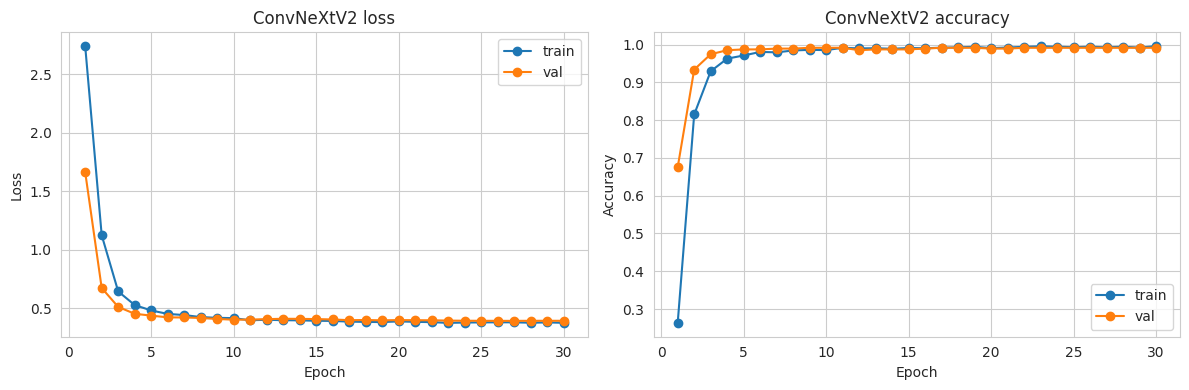

In [336]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(convnext_history_df['epoch'], convnext_history_df['train_loss'], marker='o', label='train')
if HAS_VALIDATION:
    plt.plot(convnext_history_df['epoch'], convnext_history_df['val_loss'], marker='o', label='val')
plt.title('ConvNeXtV2 loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(convnext_history_df['epoch'], convnext_history_df['train_acc'], marker='o', label='train')
if HAS_VALIDATION:
    plt.plot(convnext_history_df['epoch'], convnext_history_df['val_acc'], marker='o', label='val')
plt.title('ConvNeXtV2 accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### ConvNeXtV2 submission

This writes a separate submission file for the ConvNeXtV2 checkpoint. Compare its validation accuracy with ResNet before choosing which file to submit.

In [337]:
from pathlib import Path
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader


class TestImageDataset(Dataset):
    def __init__(self, test_dir, image_ids, transform=None):
        self.test_dir = Path(test_dir)
        self.image_ids = list(image_ids)
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = self.test_dir / image_id
        image = ImageOps.exif_transpose(Image.open(image_path)).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, image_id


sample_sub = pd.read_csv(sample_submission)
image_ids = sample_sub['image_id'].tolist()

test_dataset = TestImageDataset(test_dir, image_ids, transform=test_tfms)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

convnext_checkpoint = torch.load(CONVNEXT_CHECKPOINT_PATH, map_location=device)
convnext_model.load_state_dict(convnext_checkpoint['model_state_dict'])
print(
    f"Loaded ConvNeXtV2 checkpoint from epoch {convnext_checkpoint.get('epoch')} "
    f"with metric={convnext_checkpoint.get('val_acc', convnext_checkpoint.get('train_loss'))}"
)
convnext_model.eval()

predicted_labels = []
seen_image_ids = []

with torch.no_grad():
    for images, batch_image_ids in test_loader:
        images = images.to(device, non_blocking=True)
        if use_amp:
            with torch.cuda.amp.autocast():
                logits = convnext_model(images)
        else:
            logits = convnext_model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        predicted_labels.extend([idx_to_class[int(pred)] for pred in preds])
        seen_image_ids.extend(batch_image_ids)

convnext_submission = pd.DataFrame({
    'image_id': seen_image_ids,
    'label': predicted_labels,
})
convnext_submission = sample_sub[['image_id']].merge(convnext_submission, on='image_id', how='left')
assert convnext_submission['label'].notna().all(), 'Some test images did not receive predictions'

convnext_submission.to_csv('Submission_convnextv2_tiny.csv', index=False)
print(convnext_submission.head())
print(f"Saved Submission_convnextv2_tiny.csv with {len(convnext_submission)} rows")


Loaded ConvNeXtV2 checkpoint from epoch 27 with metric=0.9914529914529915
         image_id label
0  img_00001.jpeg     N
1  img_00002.jpeg     J
2  img_00003.jpeg     Ö
3  img_00004.jpeg     G
4  img_00005.jpeg     J
Saved Submission_convnextv2_tiny.csv with 1184 rows


## Generate submission

Predictions are made in exactly the `sample_submission.csv` image order.


In [ ]:
from torch.utils.data import Dataset
from pathlib import Path
class TestImageDataset(Dataset):
    def __init__(self, test_dir, image_ids, transform=None):
        self.test_dir = Path(test_dir)
        self.image_ids = list(image_ids)
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = self.test_dir / image_id
        image = ImageOps.exif_transpose(Image.open(image_path)).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, image_id


sample_sub = pd.read_csv(sample_submission)
image_ids = sample_sub['image_id'].tolist()

test_dataset = TestImageDataset(test_dir, image_ids, transform=test_tfms)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

checkpoint = torch.load(RESNET_CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded ResNet checkpoint from epoch {checkpoint.get('epoch')} with metric={checkpoint.get('val_acc', checkpoint.get('train_loss'))}")
model.eval()

predicted_labels = []
seen_image_ids = []

with torch.no_grad():
    for images, batch_image_ids in test_loader:
        images = images.to(device, non_blocking=True)
        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(images)
        else:
            logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        predicted_labels.extend([idx_to_class[int(pred)] for pred in preds])
        seen_image_ids.extend(batch_image_ids)

submission = pd.DataFrame({
    'image_id': seen_image_ids,
    'label': predicted_labels,
})

# Preserve the exact sample-submission order even if DataLoader behavior changes later.
submission = sample_sub[['image_id']].merge(submission, on='image_id', how='left')
assert submission['label'].notna().all(), 'Some test images did not receive predictions'

submission.to_csv('Submission.csv', index=False)
print(submission.head())
print(f"Saved Submission.csv with {len(submission)} rows")


## Training image size range

In [ ]:
from collections import Counter
from PIL import Image, ImageOps

train_image_size_rows = []
size_counter = Counter()

for class_dir in sorted([p for p in Path(train_dir).iterdir() if p.is_dir()]):
    for image_path in sorted(class_dir.iterdir()):
        if image_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        image = ImageOps.exif_transpose(Image.open(image_path))
        width, height = image.size
        train_image_size_rows.append({
            'class': class_dir.name,
            'image_path': str(image_path),
            'width': width,
            'height': height,
        })
        size_counter[(width, height)] += 1

size_df = pd.DataFrame(train_image_size_rows)

print(f'Training images scanned: {len(size_df)}')
print(f"Min width:  {size_df['width'].min()}")
print(f"Max width:  {size_df['width'].max()}")
print(f"Min height: {size_df['height'].min()}")
print(f"Max height: {size_df['height'].max()}")

print('\nMost common sizes:')
for (width, height), count in size_counter.most_common(10):
    print(f'{width}x{height}: {count}')

print('\nImages with min/max dimensions:')
display(size_df[
    (size_df['width'].isin([size_df['width'].min(), size_df['width'].max()])) |
    (size_df['height'].isin([size_df['height'].min(), size_df['height'].max()]))
].sort_values(['width', 'height']).head(20))
